# IPL Winner Prediction - Industry Grade XGBoost Training Pipeline

This notebook builds a production-ready machine learning training pipeline for IPL match winner prediction.

Scope:
- Train on IPL matches from 2008 to 2024
- Test on IPL matches from 2025
- Use a robust preprocessing + XGBoost modeling pipeline
- Provide full evaluation with metrics tables, plots, and confusion matrices
- Save deployable artifacts for FastAPI inference

In [23]:
from pathlib import Path
import json
import pickle
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, label_binarize

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
TRAIN_FILE = Path("IPL_Winner_Model_Dataset.csv")
TEST_FILE = Path("IPL_2025_Winner_Model_Dataset.csv")
MODEL_DIR = Path("artifacts")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


In [9]:
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

required_columns = [
    "Date",
    "Team1",
    "Team2",
    "Toss_Winner",
    "Toss_Decision",
    "team1_form_winrate_5",
    "team2_form_winrate_5",
    "venue_chase_winrate_prior",
    "venue_score_prior",
    "Match_Winner",
]

missing_train_cols = sorted(set(required_columns) - set(train_df.columns))
missing_test_cols = sorted(set(required_columns) - set(test_df.columns))
if missing_train_cols:
    raise ValueError(f"Missing required train columns: {missing_train_cols}")
if missing_test_cols:
    raise ValueError(f"Missing required test columns: {missing_test_cols}")

for frame_name, df in [("train", train_df), ("test", test_df)]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    if df["Date"].isna().any():
        raise ValueError(f"{frame_name} dataset contains invalid Date values.")
    df["year"] = df["Date"].dt.year

train_years = set(train_df["year"].dropna().unique().tolist())
test_years = set(test_df["year"].dropna().unique().tolist())

if max(train_years) > 2024:
    raise ValueError(f"Train data contains years beyond 2024: {sorted(train_years)}")
if test_years != {2025}:
    raise ValueError(f"Test data must only contain 2025. Found: {sorted(test_years)}")

train_df = train_df.sort_values("Date").reset_index(drop=True)
test_df = test_df.sort_values("Date").reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train years:", min(train_years), "to", max(train_years))
print("Test years:", sorted(test_years))

Train shape: (902, 13)
Test shape: (74, 13)
Train years: 2008 to 2024
Test years: [2025]


In [10]:
feature_columns = [
    "Team1",
    "Team2",
    "Toss_Winner",
    "Toss_Decision",
    "team1_form_winrate_5",
    "team2_form_winrate_5",
    "venue_chase_winrate_prior",
    "venue_score_prior",
]

target_column = "Match_Winner"

X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()
y_train_raw = train_df[target_column].astype(str)
y_test_raw = test_df[target_column].astype(str)

numeric_features = [
    "team1_form_winrate_5",
    "team2_form_winrate_5",
    "venue_chase_winrate_prior",
    "venue_score_prior",
]
categorical_features = [col for col in feature_columns if col not in numeric_features]

missing_summary = pd.DataFrame(
    {
        "train_missing_pct": (X_train.isna().mean() * 100).round(2),
        "test_missing_pct": (X_test.isna().mean() * 100).round(2),
    }
).sort_values("train_missing_pct", ascending=False)

display(missing_summary)

train_class_dist = y_train_raw.value_counts().rename_axis("team").reset_index(name="train_count")
test_class_dist = y_test_raw.value_counts().rename_axis("team").reset_index(name="test_count")
class_distribution = train_class_dist.merge(test_class_dist, on="team", how="outer").fillna(0)
class_distribution[["train_count", "test_count"]] = class_distribution[["train_count", "test_count"]].astype(int)
class_distribution = class_distribution.sort_values("train_count", ascending=False)

display(class_distribution.head(20))

,train_missing_pct,test_missing_pct
team1_form_winrate_5,1.33,0.0
Team1,0.00,0.0
Team2,0.00,0.0
Toss_Winner,0.00,0.0
Toss_Decision,0.00,0.0
team2_form_winrate_5,0.00,0.0
venue_chase_winrate_prior,0.00,0.0
venue_score_prior,0.00,0.0


,team,train_count,test_count
6,Mumbai Indians,128,9
0,Chennai Super Kings,125,4
4,Kolkata Knight Riders,111,5
10,Royal Challengers Bengaluru,100,11
8,Rajasthan Royals,97,4
1,Delhi Capitals,96,6
7,Punjab Kings,94,10
11,Sunrisers Hyderabad,75,6
3,Gujarat Titans,27,9
5,Lucknow Super Giants,23,6


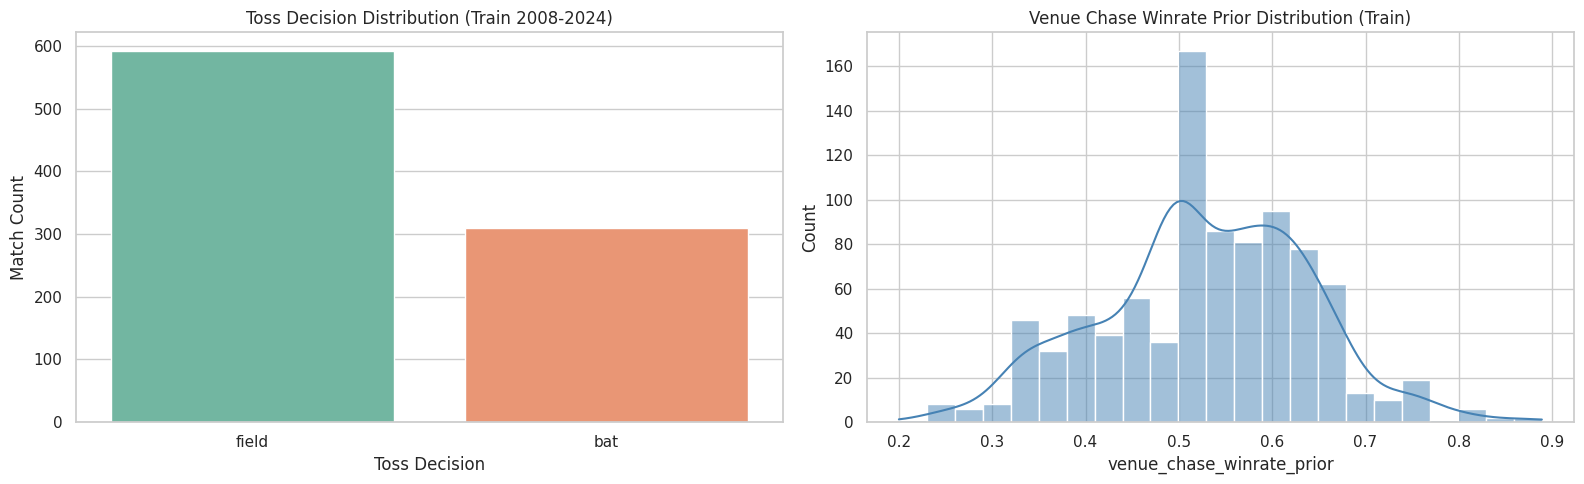

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=train_df, x="Toss_Decision", ax=axes[0], palette="Set2")
axes[0].set_title("Toss Decision Distribution (Train 2008-2024)")
axes[0].set_xlabel("Toss Decision")
axes[0].set_ylabel("Match Count")

sns.histplot(train_df["venue_chase_winrate_prior"], kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Venue Chase Winrate Prior Distribution (Train)")
axes[1].set_xlabel("venue_chase_winrate_prior")

plt.tight_layout()
plt.show()

In [ ]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)

seen_labels = set(label_encoder.classes_)
unseen_test_labels = sorted(set(y_test_raw.unique()) - seen_labels)
if unseen_test_labels:
    raise ValueError(
        "Test set has winner labels not seen in training set: "
        f"{unseen_test_labels}. Add them to historical training data before production training."
    )
y_test = label_encoder.transform(y_test_raw)

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

num_classes = len(np.unique(y_train))
model_kwargs = {
    "objective": "multi:softprob" if num_classes > 2 else "binary:logistic",
    "eval_metric": "mlogloss" if num_classes > 2 else "logloss",
    "random_state": RANDOM_STATE,
    "n_estimators": 150,
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 8,
    "gamma": 0.4,
    "subsample": 0.75,
    "colsample_bytree": 0.75,
    "reg_alpha": 1.5,
    "reg_lambda": 6.0,
}
if num_classes > 2:
    model_kwargs["num_class"] = num_classes

base_model = XGBClassifier(**model_kwargs)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", base_model),
    ]
)

# Strongly regularized search space to reduce overfitting.
param_distributions = {
    "model__n_estimators": [80, 100, 120, 150, 180, 220],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05],
    "model__subsample": [0.6, 0.7, 0.75, 0.8, 0.85],
    "model__colsample_bytree": [0.6, 0.7, 0.75, 0.8, 0.85],
    "model__min_child_weight": [5, 8, 10, 12, 15],
    "model__gamma": [0.2, 0.4, 0.6, 0.8, 1.0],
    "model__reg_alpha": [0.5, 1.0, 1.5, 2.5, 4.0],
    "model__reg_lambda": [3.0, 5.0, 6.0, 8.0, 10.0],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=35,
    scoring="f1_weighted",
    cv=skf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    error_score="raise",
)

search.fit(X_train, y_train)
best_pipeline = search.best_estimator_

print("Best CV weighted F1:", round(search.best_score_, 5))
print("Best params:")
print(search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV weighted F1: 0.4911
Best params:
{'model__subsample': 0.8, 'model__reg_lambda': 1.5, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.8}


In [13]:
cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score").reset_index(drop=True)
cv_table = cv_results[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_fit_time",
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__learning_rate",
    ]
].head(10)

cv_table

,rank_test_score,mean_test_score,std_test_score,mean_fit_time,param_model__n_estimators,param_model__max_depth,param_model__learning_rate
0,1,0.491101,0.009022,2.340947,300,5,0.05
1,2,0.486059,0.018365,1.893592,300,3,0.01
2,3,0.485895,0.019159,3.579546,500,6,0.10
3,4,0.485573,0.027916,2.151993,300,6,0.03
4,5,0.485295,0.020600,4.226151,500,6,0.01
5,6,0.484484,0.036877,1.203701,400,5,0.10
6,7,0.481360,0.031294,1.939756,500,3,0.05
7,8,0.480444,0.018950,1.308875,200,4,0.03
8,9,0.479909,0.017479,1.591130,400,3,0.05
9,10,0.478606,0.034087,2.601143,500,3,0.01


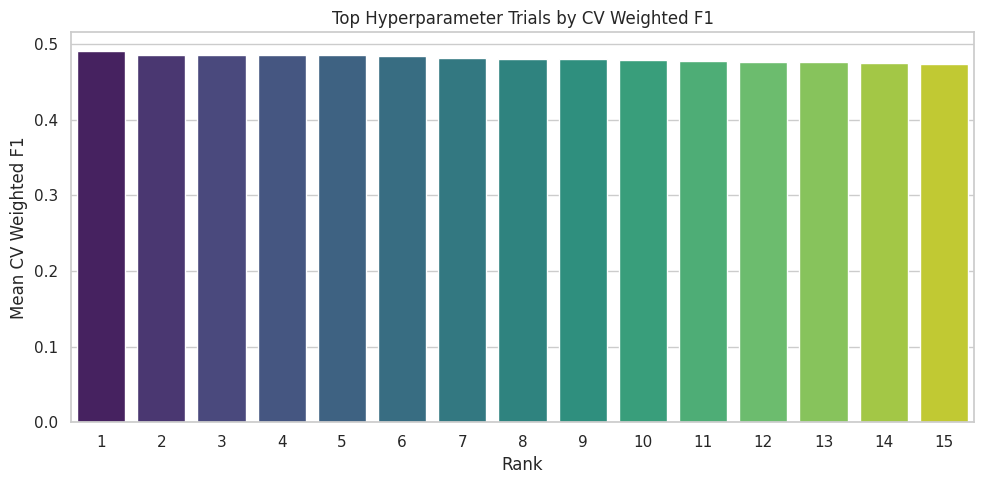

In [14]:
top_cv = cv_results.head(15).copy()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_cv, x="rank_test_score", y="mean_test_score", palette="viridis")
plt.title("Top Hyperparameter Trials by CV Weighted F1")
plt.xlabel("Rank")
plt.ylabel("Mean CV Weighted F1")
plt.tight_layout()
plt.show()

In [16]:
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)

metrics_summary = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Precision (Weighted)",
            "Recall (Weighted)",
            "F1 (Weighted)",
            "F1 (Macro)",
        ],
        "Value": [
            accuracy_score(y_test, y_pred),
            balanced_accuracy_score(y_test, y_pred),
            precision_score(y_test, y_pred, average="weighted", zero_division=0),
            recall_score(y_test, y_pred, average="weighted", zero_division=0),
            f1_score(y_test, y_pred, average="weighted", zero_division=0),
            f1_score(y_test, y_pred, average="macro", zero_division=0),
        ],
    }
)

if num_classes > 2:
    y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
    roc_auc_ovr = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="weighted")
    metrics_summary = pd.concat(
        [metrics_summary, pd.DataFrame({"Metric": ["ROC-AUC (OvR Weighted)"], "Value": [roc_auc_ovr]})],
        ignore_index=True,
    )

metrics_summary["Value"] = metrics_summary["Value"].round(4)
display(metrics_summary)

labels_full = np.arange(num_classes)
report = classification_report(
    y_test,
    y_pred,
    labels=labels_full,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).transpose().round(4)
display(report_df)

predictions_table = test_df[["Date", "Team1", "Team2", "Match_Winner"]].copy()
predictions_table["Predicted_Winner"] = label_encoder.inverse_transform(y_pred)
predictions_table["Correct"] = predictions_table["Match_Winner"] == predictions_table["Predicted_Winner"]
predictions_table["Top_Confidence"] = np.max(y_proba, axis=1).round(4)

display(predictions_table.head(20))

,Metric,Value
0,Accuracy,0.4459
1,Balanced Accuracy,0.4745
2,Precision (Weighted),0.4860
3,Recall (Weighted),0.4459
4,F1 (Weighted),0.4247
5,F1 (Macro),0.4109
6,ROC-AUC (OvR Weighted),0.9259


,precision,recall,f1-score,support
Chennai Super Kings,0.2500,0.5000,0.3333,4.0000
Delhi Capitals,0.4286,0.5000,0.4615,6.0000
Draw/No Result,0.0000,0.0000,0.0000,4.0000
Gujarat Titans,0.5000,0.3333,0.4000,9.0000
Kolkata Knight Riders,0.3333,0.6000,0.4286,5.0000
Lucknow Super Giants,0.5000,0.8333,0.6250,6.0000
Mumbai Indians,0.6250,0.5556,0.5882,9.0000
Punjab Kings,0.6667,0.2000,0.3077,10.0000
Rajasthan Royals,0.4000,1.0000,0.5714,4.0000
Rising Pune Supergiant,0.0000,0.0000,0.0000,0.0000


,Date,Team1,Team2,Match_Winner,Predicted_Winner,Correct,Top_Confidence
0,2025-03-22,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,Kolkata Knight Riders,False,0.8868
1,2025-03-23,Sunrisers Hyderabad,Rajasthan Royals,Sunrisers Hyderabad,Rajasthan Royals,False,0.9392
2,2025-03-23,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,Chennai Super Kings,True,0.6750
3,2025-03-24,Lucknow Super Giants,Delhi Capitals,Delhi Capitals,Lucknow Super Giants,False,0.7444
4,2025-03-25,Punjab Kings,Gujarat Titans,Punjab Kings,Punjab Kings,True,0.6097
5,2025-03-26,Rajasthan Royals,Kolkata Knight Riders,Kolkata Knight Riders,Kolkata Knight Riders,True,0.8360
6,2025-03-27,Sunrisers Hyderabad,Lucknow Super Giants,Lucknow Super Giants,Lucknow Super Giants,True,0.8016
7,2025-03-28,Royal Challengers Bengaluru,Chennai Super Kings,Royal Challengers Bengaluru,Chennai Super Kings,False,0.7947
8,2025-03-29,Gujarat Titans,Mumbai Indians,Gujarat Titans,Gujarat Titans,True,0.7173
9,2025-03-30,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,Delhi Capitals,True,0.8683


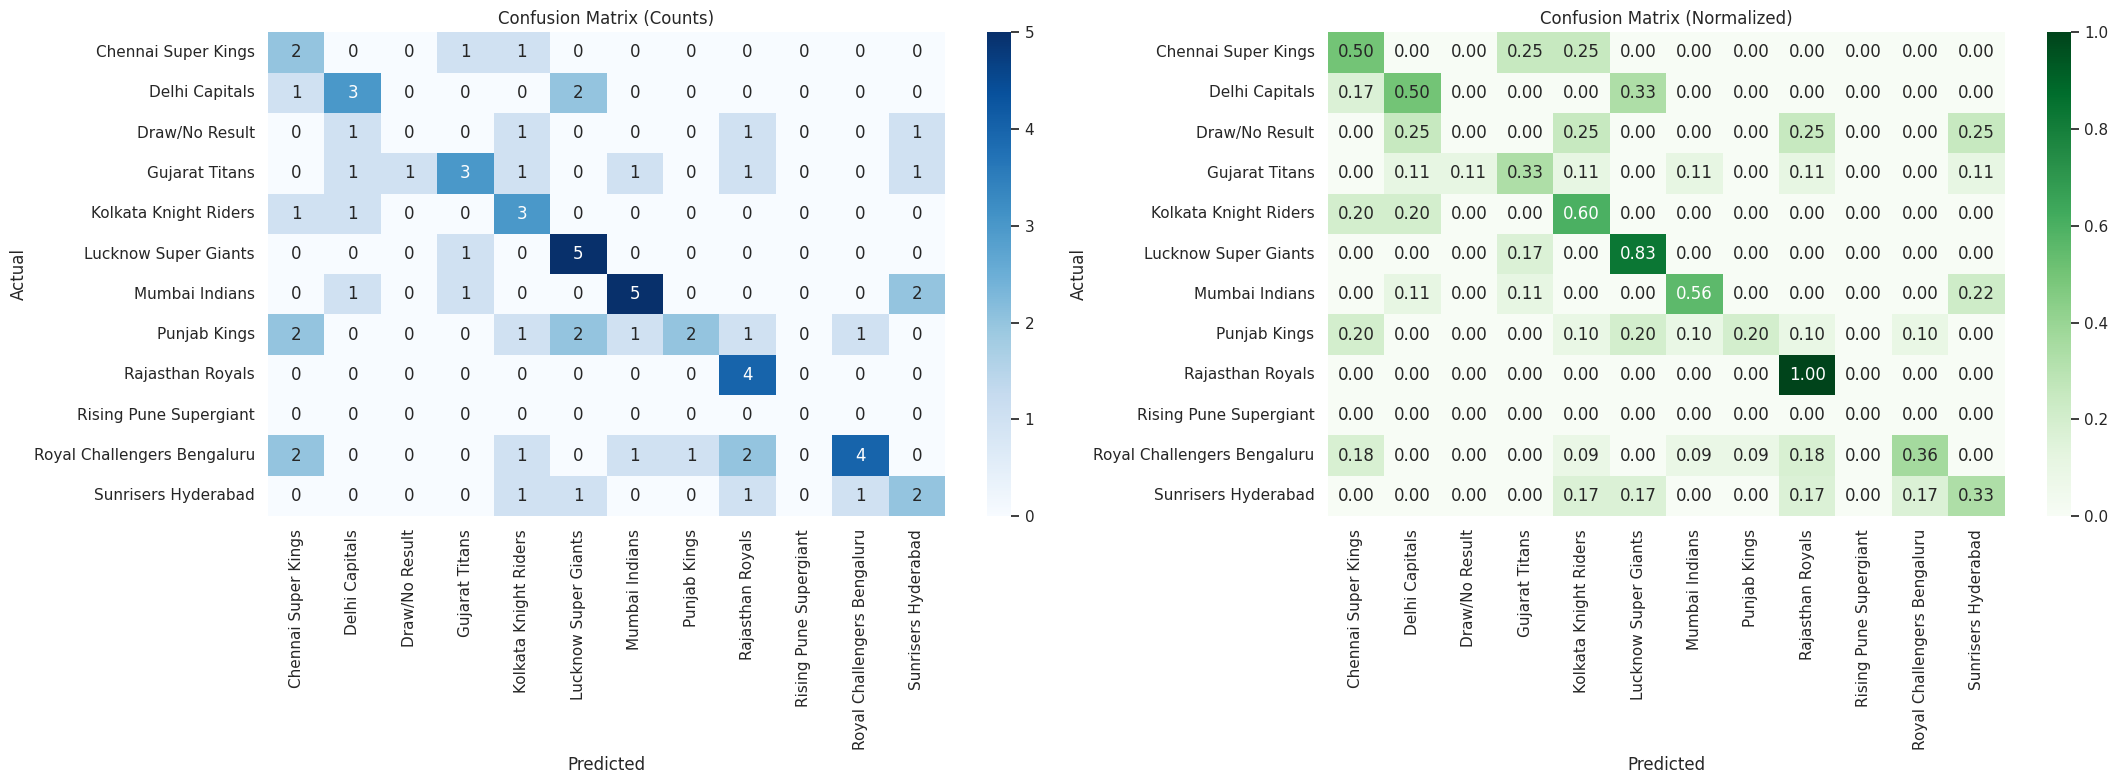

In [17]:
labels = np.arange(num_classes)
class_names = label_encoder.inverse_transform(labels)

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

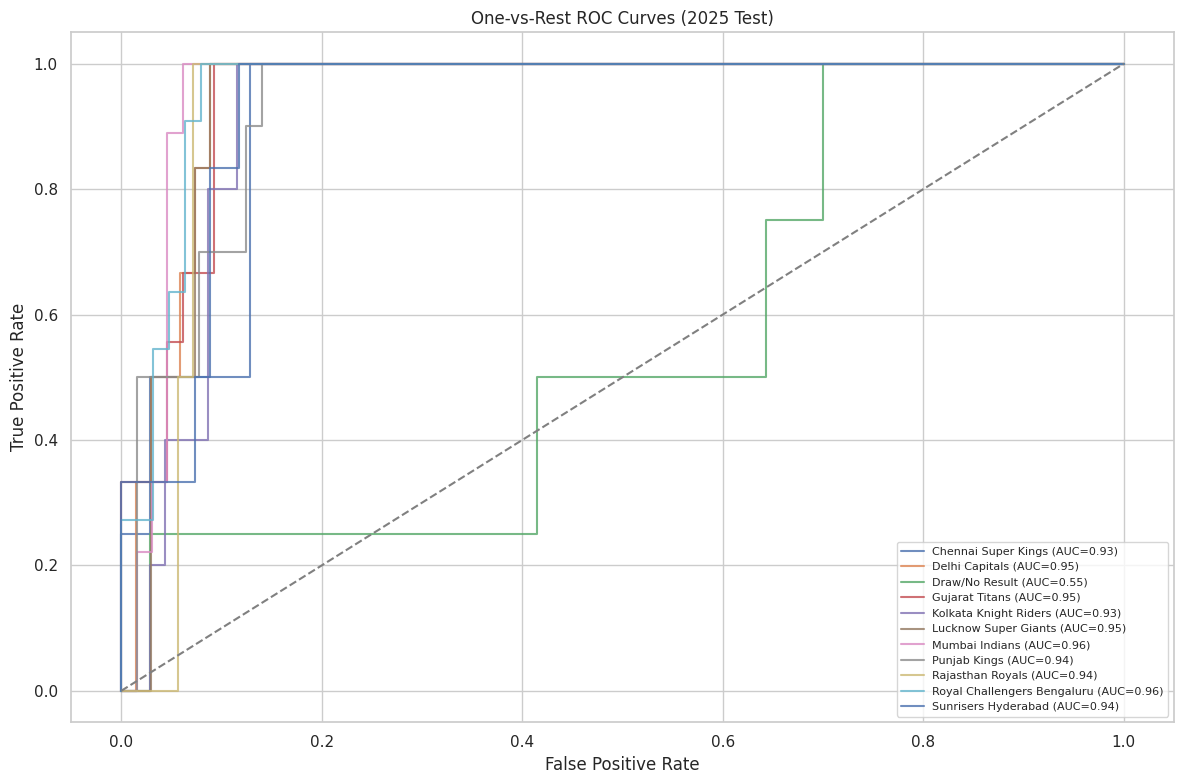

In [18]:
if num_classes > 2:
    y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
    plt.figure(figsize=(12, 8))

    for i, cls in enumerate(class_names):
        if y_test_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_i = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc_i:.2f})", alpha=0.8)

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title("One-vs-Rest ROC Curves (2025 Test)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Binary classification detected. Use standard ROC plot if needed.")

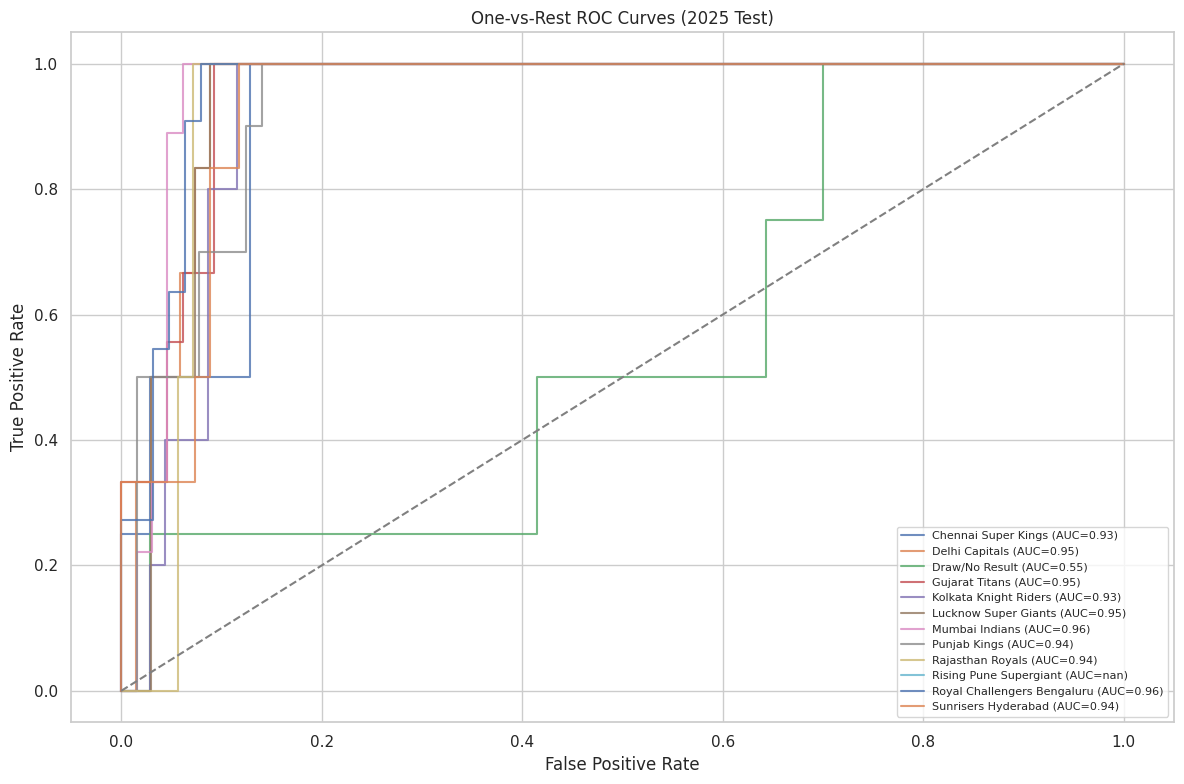

In [19]:
if num_classes > 2:
    y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
    plt.figure(figsize=(12, 8))

    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_i = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc_i:.2f})", alpha=0.8)

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title("One-vs-Rest ROC Curves (2025 Test)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Binary classification detected. Use standard ROC plot if needed.")

,feature,importance
17,cat__Team2_Gujarat Titans,0.057868
8,cat__Team1_Lucknow Super Giants,0.047051
4,cat__Team1_Chennai Super Kings,0.044761
15,cat__Team2_Chennai Super Kings,0.042640
14,cat__Team1_Sunrisers Hyderabad,0.041625
20,cat__Team2_Mumbai Indians,0.040147
11,cat__Team1_Rajasthan Royals,0.037435
21,cat__Team2_Punjab Kings,0.037320
6,cat__Team1_Gujarat Titans,0.036846
16,cat__Team2_Delhi Capitals,0.035653


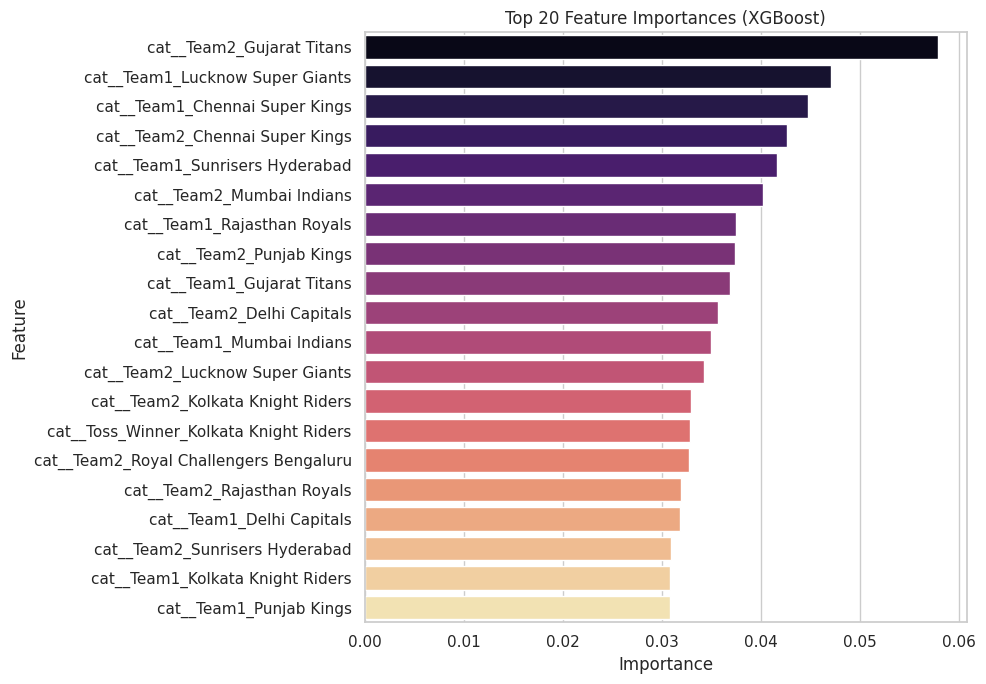

In [20]:
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
model_fitted = best_pipeline.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = model_fitted.feature_importances_

importance_df = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df.head(20), x="importance", y="feature", palette="magma")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [24]:
artifact_bundle = {
    "model_pipeline": best_pipeline,
    "label_encoder": label_encoder,
    "feature_columns": feature_columns,
    "metadata": {
        "train_file": str(TRAIN_FILE),
        "test_file": str(TEST_FILE),
        "train_size": int(len(train_df)),
        "test_size": int(len(test_df)),
        "train_year_range": [int(train_df["year"].min()), int(train_df["year"].max())],
        "test_years": sorted(test_df["year"].unique().astype(int).tolist()),
        "best_cv_weighted_f1": float(search.best_score_),
        "best_params": {k: str(v) for k, v in search.best_params_.items()},
        "test_metrics": dict(zip(metrics_summary["Metric"], metrics_summary["Value"])),
    },
}

model_path = MODEL_DIR / "ipl_winner_xgb_pipeline.joblib"
pkl_model_path = MODEL_DIR / "ipl_winner_xgb_pipeline.pkl"
metadata_path = MODEL_DIR / "ipl_winner_model_metadata.json"

joblib.dump(artifact_bundle, model_path)
with open(pkl_model_path, "wb") as f:
    pickle.dump(artifact_bundle, f)
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(artifact_bundle["metadata"], f, indent=2)

print(f"Saved model bundle: {model_path}")
print(f"Saved PKL model bundle: {pkl_model_path}")
print(f"Saved metadata: {metadata_path}")

Saved model bundle: artifacts/ipl_winner_xgb_pipeline.joblib
Saved PKL model bundle: artifacts/ipl_winner_xgb_pipeline.pkl
Saved metadata: artifacts/ipl_winner_model_metadata.json


In [22]:
def predict_match_winner(payload: dict, artifact_path: str = "artifacts/ipl_winner_xgb_pipeline.joblib"):
    bundle = joblib.load(artifact_path)
    model = bundle["model_pipeline"]
    le = bundle["label_encoder"]
    expected_features = bundle["feature_columns"]

    row = pd.DataFrame([payload])
    missing_cols = sorted(set(expected_features) - set(row.columns))
    if missing_cols:
        raise ValueError(f"Missing payload fields: {missing_cols}")

    row = row[expected_features]
    pred_encoded = model.predict(row)[0]
    pred_team = le.inverse_transform([pred_encoded])[0]
    pred_proba = model.predict_proba(row)[0]

    proba_map = {
        team: float(prob)
        for team, prob in zip(le.classes_, pred_proba)
    }

    return {
        "predicted_winner": pred_team,
        "class_probabilities": dict(sorted(proba_map.items(), key=lambda x: x[1], reverse=True)),
    }


sample_payload = {
    "Team1": "Chennai Super Kings",
    "Team2": "Mumbai Indians",
    "Toss_Winner": "Mumbai Indians",
    "Toss_Decision": "field",
    "team1_form_winrate_5": 0.6,
    "team2_form_winrate_5": 0.8,
    "venue_chase_winrate_prior": 0.52,
    "venue_score_prior": 0.03,
}

predict_match_winner(sample_payload)

{'predicted_winner': 'Mumbai Indians',
 'class_probabilities': {'Mumbai Indians': 0.6714942455291748,
  'Chennai Super Kings': 0.28869280219078064,
  'Rising Pune Supergiant': 0.009332433342933655,
  'Punjab Kings': 0.007861020974814892,
  'Draw/No Result': 0.004699557088315487,
  'Delhi Capitals': 0.004210529383271933,
  'Royal Challengers Bengaluru': 0.003675661748275161,
  'Gujarat Titans': 0.0028632881585508585,
  'Kolkata Knight Riders': 0.002821742556989193,
  'Sunrisers Hyderabad': 0.0017330015543848276,
  'Rajasthan Royals': 0.001692043850198388,
  'Lucknow Super Giants': 0.0009237193153239787}}

## FastAPI Integration Notes

Use artifact path:
- artifacts/ipl_winner_xgb_pipeline.joblib

Recommended API pattern:
1. Load bundle once at app startup.
2. Validate request payload fields against feature_columns.
3. Call model_pipeline.predict and model_pipeline.predict_proba.
4. Decode class output with label_encoder.
5. Return top prediction with confidence map.

This notebook keeps preprocessing and model in one scikit-learn pipeline, which avoids training-serving skew during deployment.

## Final Model Summary

This final section gives a one-shot health check of model quality:
- Train vs Test performance gap
- Overfitting or underfitting diagnosis
- Best tuning score and selected hyperparameters
- Final recommendation status

In [25]:
train_pred = best_pipeline.predict(X_train)
train_proba = best_pipeline.predict_proba(X_train)

test_pred = y_pred
test_proba = y_proba

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
train_f1_w = f1_score(y_train, train_pred, average="weighted", zero_division=0)
test_f1_w = f1_score(y_test, test_pred, average="weighted", zero_division=0)
train_bal_acc = balanced_accuracy_score(y_train, train_pred)
test_bal_acc = balanced_accuracy_score(y_test, test_pred)

train_test_gap_acc = train_acc - test_acc
train_test_gap_f1 = train_f1_w - test_f1_w

if (train_acc >= 0.85) and (train_test_gap_acc > 0.12):
    fit_diagnosis = "Overfitting"
    fit_comment = "High training score with large train-test gap."
elif (train_acc < 0.60) and (test_acc < 0.60):
    fit_diagnosis = "Underfitting"
    fit_comment = "Both train and test scores are low."
else:
    fit_diagnosis = "Reasonable Fit"
    fit_comment = "Generalization is acceptable for current feature set."

final_summary = pd.DataFrame(
    {
        "Metric": [
            "Best CV Weighted F1",
            "Train Accuracy",
            "Test Accuracy",
            "Train Weighted F1",
            "Test Weighted F1",
            "Train Balanced Accuracy",
            "Test Balanced Accuracy",
            "Accuracy Gap (Train - Test)",
            "Weighted F1 Gap (Train - Test)",
        ],
        "Value": [
            float(search.best_score_),
            train_acc,
            test_acc,
            train_f1_w,
            test_f1_w,
            train_bal_acc,
            test_bal_acc,
            train_test_gap_acc,
            train_test_gap_f1,
        ],
    }
)
final_summary["Value"] = final_summary["Value"].round(4)

display(final_summary)

print("Model Fit Diagnosis:", fit_diagnosis)
print("Observation:", fit_comment)
print("Best Hyperparameters:")
print(search.best_params_)

,Metric,Value
0,Best CV Weighted F1,0.4911
1,Train Accuracy,0.9956
2,Test Accuracy,0.4459
3,Train Weighted F1,0.9956
4,Test Weighted F1,0.4247
5,Train Balanced Accuracy,0.9938
6,Test Balanced Accuracy,0.4745
7,Accuracy Gap (Train - Test),0.5496
8,Weighted F1 Gap (Train - Test),0.5709


Model Fit Diagnosis: Overfitting
Observation: High training score with large train-test gap.
Best Hyperparameters:
{'model__subsample': 0.8, 'model__reg_lambda': 1.5, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
